# 01 - Análisis Exploratorio de Datos

## 1. Comprensión del Problema

La pérdida de clientes (**customer churn**) representa uno de los principales desafíos para las empresas, ya que la adquisición de nuevos clientes suele requerir mayores recursos que la retención de clientes existentes.

En este proyecto se busca desarrollar una solución basada en Machine Learning capaz de identificar clientes con alta probabilidad de abandonar un servicio de telecomunicaciones, permitiendo anticipar posibles bajas y apoyar la definición de estrategias de retención.

El análisis se complementará con una etapa de segmentación de clientes mediante aprendizaje no supervisado, con el objetivo de identificar grupos de clientes con características y comportamientos similares.

### 1.1 Objetivos del proyecto

Los principales objetivos son:

- Analizar las características de los clientes y su relación con el abandono del servicio.
- Desarrollar un modelo de clasificación binaria para predecir la probabilidad de churn.
- Identificar los factores más relevantes asociados a la pérdida de clientes mediante técnicas de interpretabilidad.
- Crear segmentos de clientes utilizando técnicas de clustering para descubrir diferentes perfiles dentro de la base de clientes.
- Desplegar una aplicación interactiva que permita realizar predicciones y explorar los segmentos identificados.

### 1.2 Definición del problema de Machine Learning

Este proyecto se plantea como un problema de clasificación binaria supervisada.

La variable objetivo será:

**Churn**

- `Yes`: el cliente abandonó el servicio.
- `No`: el cliente continúa utilizando el servicio.

El modelo aprenderá patrones a partir de las características históricas de los clientes para estimar la probabilidad de abandono de nuevos clientes. Adicionalmente, se desarrollará un análisis de segmentación no supervisada utilizando las características de los clientes, sin considerar la variable objetivo, con el propósito de identificar grupos con comportamientos similares.

### 1.3 Pregunta de negocio

> ¿Es posible identificar anticipadamente a los clientes con mayor riesgo de abandono y comprender los perfiles de clientes existentes para diseñar mejores estrategias de retención?

## 2. Descripción del Dataset

El dataset utilizado en este proyecto corresponde a información histórica de clientes de una empresa de telecomunicaciones, con el objetivo de analizar los factores asociados al abandono del servicio.

Cada registro representa un cliente y contiene información relacionada con sus características demográficas, servicios contratados, tipo de contrato, información de facturación y comportamiento dentro de la relación comercial.

### 2.1 Información general

- **Número de registros:** 7,043 clientes.
- **Número de variables:** 21 columnas.
- **Variable objetivo:** `Churn`.
- **Tipo de problema principal:** Clasificación binaria.
- **Problema complementario:** Segmentación de clientes mediante clustering.

### 2.2 Descripción de las variables

El dataset contiene variables agrupadas en las siguientes categorías:

#### Información demográfica

Características generales del cliente:

- Género (`gender`).
- Edad del cliente (``SeniorCitizen	``).
- Estado de pareja (`Partner`).
- Dependientes (`Dependents`).

#### Información de cuenta

Variables relacionadas con la antigüedad y relación comercial:

- Antigüedad del cliente (`tenure`).
- Tipo de contrato (`Contract`).
- Facturación electrónica (`PaperlessBilling`).
- Método de pago (`PaymentMethod`).

#### Servicios contratados

Información sobre los servicios utilizados por cada cliente:

- Servicio telefónico (`PhoneService`).
- Múltiples líneas (`MultipleLines`).
- Servicio de internet (`InternetService`).
- Seguridad en línea (`OnlineSecurity`).
- Respaldo en línea (`OnlineBackup`).
- Protección del dispositivo (`DeviceProtection`).
- Soporte técnico (`TechSupport`).
- Servicios de streaming (`StreamingTV`, `StreamingMovies`).

#### Información financiera

Variables relacionadas con los pagos del cliente:

- Cargos mensuales (`MonthlyCharges`).
- Cargos totales acumulados (`TotalCharges`).

#### Variable objetivo

La variable objetivo del proyecto es:

**`Churn`**

Representa si el cliente abandonó el servicio:

- `Yes`: el cliente canceló el servicio.
- `No`: el cliente continúa siendo cliente.

### 2.3 Fuente del Dataset

El dataset corresponde al conjunto **Telco Customer Churn**, ampliamente utilizado para análisis de retención de clientes y desarrollo de modelos predictivos de clasificación.

## 3. Inspección Inicial

En esta sección se realiza una revisión inicial del dataset con el objetivo de comprender su tamaño, estructura y tipos de variables.

### 3.1 Importación de librerías y carga del dataset

In [13]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

# Load the autoreload extension to automatically reload modules when they change
# Set autoreload mode to 2: reload all modules before executing user code
%load_ext autoreload
%autoreload 2 

# import eda modules
from src.eda.visualizations import (
    plot_categorical_distributions,
    plot_categorical_churn_rates
)

from src.eda.statistical_test import(
    chi_square_analysis
)

# Load dataset
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

df.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.2 Inspección inicial de los datos

In [2]:
# Dataset dimensions
print(f'Dataset dimensions: \nRows: {df.shape[0]}, Columns: {df.shape[1]}')

Dataset dimensions: 
Rows: 7043, Columns: 21


In [3]:
# General structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Count duplicated rows
print(f"Total duplicated rows: {df.duplicated().sum()}")

Total duplicated rows: 0


In [5]:
# Count missing values per column
print("========= Missing values in each column =========")
with pd.option_context('display.max_rows', None):
    print(df.isnull().sum().sort_values(ascending=False))

========= Missing values in each column =========
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


A continuación se realizará un Análisis Exploratorio de Datos (EDA), cuyo objetivo será comprender las características principales de los clientes y analizar la relación entre las variables disponibles y el abandono del servicio (**Churn**).

Durante las siguientes etapas se explorará la variable objetivo y los diferentes grupos de variables del dataset, identificando patrones, diferencias entre los clientes que abandonaron y aquellos que permanecieron activos, así como posibles factores asociados con una mayor probabilidad de cancelación.

Además del análisis descriptivo y visual, se utilizarán pruebas estadísticas y medidas de asociación cuando sean apropiadas para complementar los hallazgos observados y evaluar si determinadas relaciones presentan evidencia estadística.

El análisis se enfocará principalmente en responder preguntas como:

- ¿Cuál es la proporción de clientes que abandonan el servicio?
- ¿Qué características demográficas presentan mayor relación con el churn?
- ¿Cómo se relacionan el tipo de contrato, los servicios contratados y la antigüedad del cliente con el abandono?
- ¿Existe alguna relación entre los cargos del cliente y la probabilidad de abandono?

Los hallazgos obtenidos durante esta etapa servirán como base para identificar variables candidatas para el modelo y orientar la creación de características derivadas (*feature engineering*) en las siguientes fases del proyecto.

## 4. Análisis de la Variable Objetivo (`Churn`)

La variable objetivo del proyecto es `Churn`, que indica si un cliente abandonó el servicio de la compañía. Antes de analizar la relación entre las características de los clientes y el abandono, es necesario comprender la distribución de esta variable y determinar si existe un desbalance entre sus categorías.

Este análisis permitirá establecer una referencia inicial sobre la proporción de clientes que abandonan el servicio y aquellos que permanecen, además de identificar posibles consideraciones que deberán tenerse en cuenta durante la etapa de modelado.

El análisis de esta sección se centrará en:

- Examinar la distribución de las categorías de `Churn`.
- Calcular la cantidad y proporción de clientes que abandonaron y permanecieron.
- Evaluar el nivel de desbalance de la variable objetivo.
- Identificar las implicaciones de esta distribución para la selección de métricas de evaluación del modelo.

Una vez comprendida la distribución de la variable objetivo, se analizará cómo las diferentes características de los clientes se relacionan con el abandono del servicio.

### 4.1 Distribución de la variable objetivo

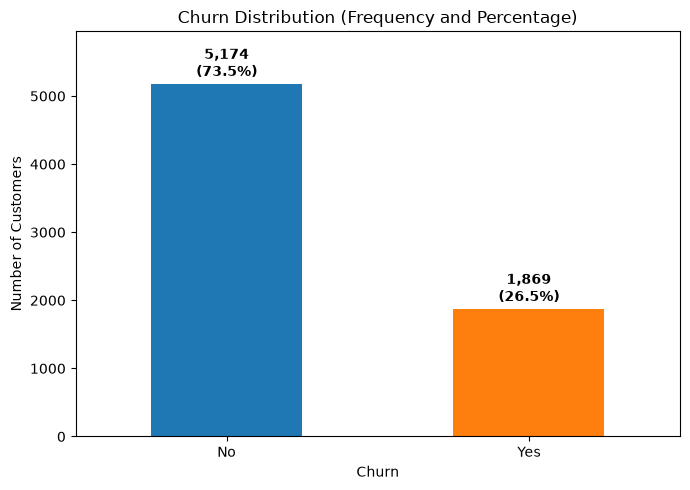

In [6]:
# Calculate counts and percentages ensuring matching indices
churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True).mul(100)

# Initialize a single plot figure
fig, ax = plt.subplots(figsize=(7, 5))

# Plot absolute frequencies
churn_counts.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e"])
ax.set_title("Churn Distribution (Frequency and Percentage)")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)

# Annotate bars with both absolute count and percentage values
for i, label in enumerate(churn_counts.index):
    count = churn_counts[label]
    pct = churn_percentages[label]
    
    ax.text(
        i, 
        count + (churn_counts.max() * 0.01), 
        f"{count:,}\n({pct:.1f}%)", 
        ha="center", 
        va="bottom", 
        fontsize=10, 
        fontweight="bold"
    )

# Adjust y-axis limit to prevent label clipping
ax.set_ylim(0, churn_counts.max() * 1.15)

plt.tight_layout()
plt.show()


De los 7,043 clientes presentes en el dataset, 5,174 (73.5%) permanecen con la compañía (`No`), mientras que 1,869 (26.5%) han abandonado el servicio (`Yes`).

Por lo tanto, aproximadamente 1 de cada 4 clientes corresponde a un caso de churn.

La distribución muestra un desbalance moderado entre las clases. Aunque la categoría `No` representa la mayoría de los registros, la clase `Yes` cuenta con un número considerable de observaciones para desarrollar un modelo de clasificación.

### 4.2 Implicaciones para el Modelado

El desbalance observado debe ser considerado durante la evaluación de los modelos. En este escenario, un modelo podría alcanzar un nivel elevado de `Accuracy` simplemente al predecir mayoritariamente la clase `No`, sin necesariamente tener una buena capacidad para identificar a los clientes que abandonan.

Por esta razón, durante la etapa de modelado no se utilizará `Accuracy` como única métrica de evaluación. Se prestará especial atención a métricas como *Precision, Recall, F1-Score y ROC-AUC*, considerando especialmente el desempeño sobre la clase minoritaria `Yes`.

La distribución de la variable objetivo proporciona así un punto de partida para comprender el problema de clasificación. Sin embargo, conocer únicamente cuántos clientes abandonan no permite explicar qué características están asociadas con el churn.

Por ello, en las siguientes secciones se analizarán los diferentes grupos de variables disponibles en el dataset, comparando el comportamiento de los clientes que permanecieron con aquellos que abandonaron el servicio. El objetivo será identificar patrones y relaciones que puedan aportar información relevante para las etapas posteriores de feature engineering y modelado.

## 5. Análisis de Variables Demográficas

En esta sección se analizará la relación entre las características demográficas de los clientes y el abandono del servicio (`Churn`).

El objetivo es determinar si existen diferencias en las tasas de abandono entre distintos perfiles demográficos y si estas variables podrían aportar información relevante para la predicción del churn.

Las variables que se analizarán son:

- `gender`: género del cliente.
- `SeniorCitizen`: indica si el cliente pertenece al grupo de adultos mayores.
- `Partner`: indica si el cliente tiene pareja.
- `Dependents`: indica si el cliente tiene dependientes.

Para las variables categóricas se analizará principalmente la **tasa de churn de cada categoría**, ya que esta métrica permite comparar directamente la proporción de clientes que abandonaron el servicio dentro de cada grupo. Además de observar las diferencias en las tasas de abandono, se considerará el tamaño de cada grupo para evitar interpretar diferencias basadas en categorías con un número reducido de observaciones.

Posteriormente, las diferencias observadas se complementarán mediante la **prueba Chi-cuadrado de independencia**, con el objetivo de evaluar si existe evidencia estadística de una asociación entre cada variable demográfica y `Churn`. Asimismo, se utilizará **Cramér's V** para estimar la magnitud de dichas asociaciones.

Los resultados de este análisis permitirán identificar posibles patrones de asociación entre las características demográficas y el churn, así como determinar qué variables podrían aportar información relevante para nuestro problema de clasificación.

### 5.1 Distribucion de variables demográficas

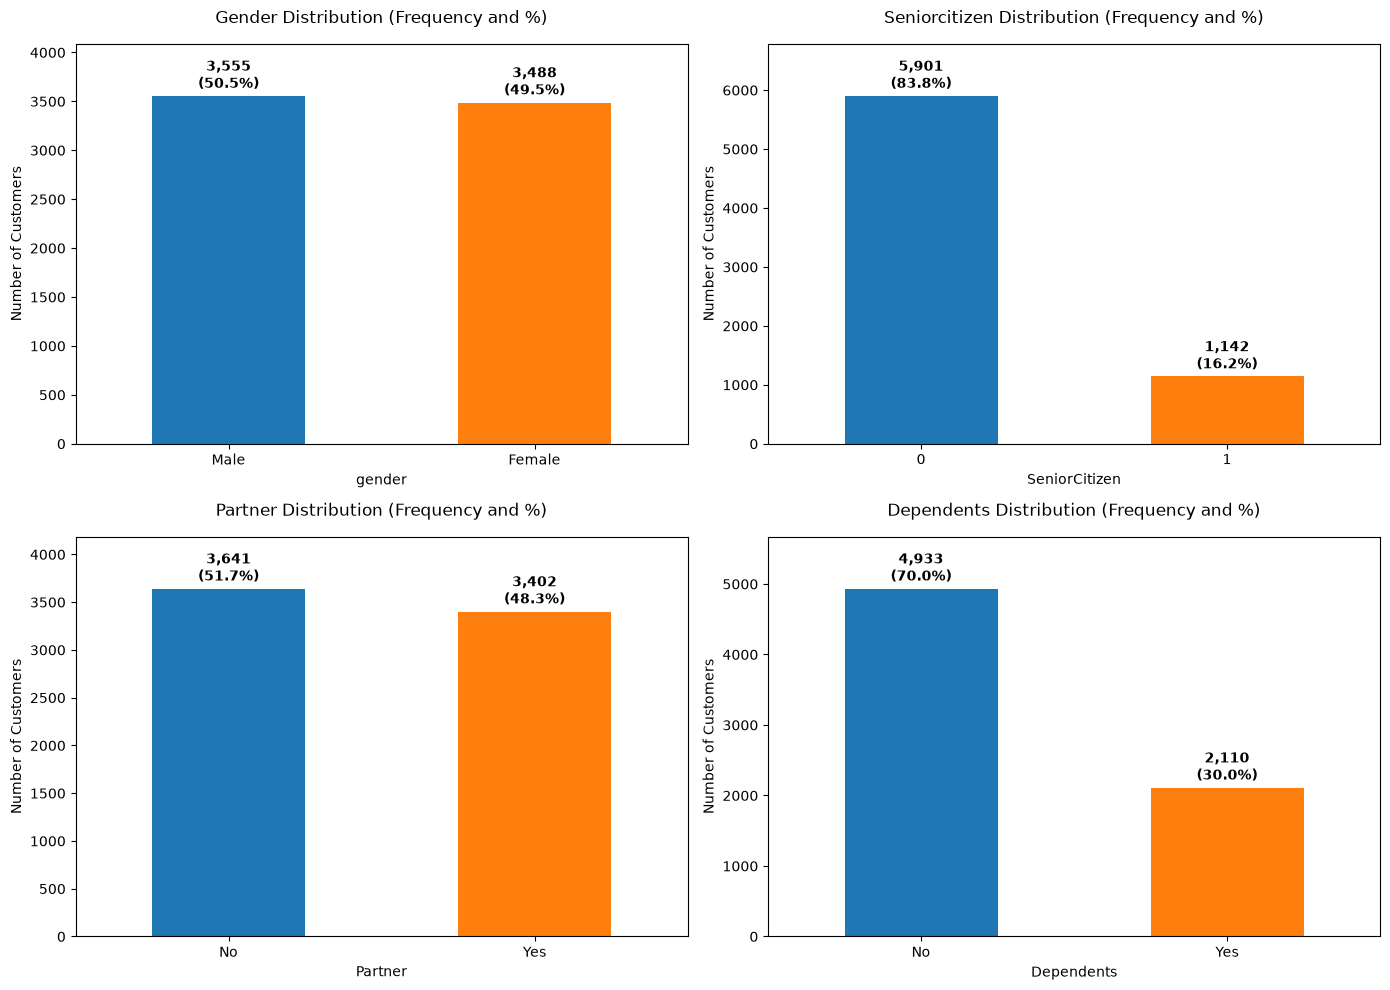

In [7]:
# Define the list of customer demographic features to analyze
demographic_features = ["gender", "SeniorCitizen", "Partner", "Dependents"]

# Plot distributions for the demographic features
plot_categorical_distributions(df, demographic_features)

La distribución de las variables demográficas muestra diferentes niveles de representación entre sus categorías.

En el caso de `gender`, la distribución es prácticamente equilibrada, con 3,555 clientes (50.48%) identificados como hombres y 3,488 (49.52%) como mujeres. La diferencia de menos de un punto porcentual indica que no existe un desbalance relevante entre ambas categorías.

La variable `SeniorCitizen` presenta una distribución más desigual. 5,901 clientes (83.79%) no pertenecen al grupo de adultos mayores, mientras que 1,142 (16.21%) sí pertenecen a este grupo. Esta diferencia deberá considerarse al analizar posteriormente las tasas de churn, especialmente al comparar grupos con tamaños diferentes.

En `Partner`, la distribución es relativamente equilibrada: 3,641 clientes (51.70%) no tienen pareja y 3,402 (48.30%) sí tienen pareja. Por lo tanto, ambas categorías cuentan con una cantidad suficiente de observaciones para realizar comparaciones posteriores.

Finalmente, `Dependents` presenta una distribución más desigual. 4,933 clientes (70.04%) no tienen dependientes, mientras que 2,110 (29.96%) sí los tienen. Al igual que en `SeniorCitizen`, el tamaño de los grupos deberá considerarse al interpretar las diferencias en las tasas de abandono.

En general, las variables presentan tamaños de grupo suficientes para analizar su relación con `Churn`. Sin embargo, la distribución de las categorías por sí sola no permite determinar si existe una asociación con el abandono. Por ello, el siguiente análisis comparará la tasa de churn dentro de cada categoría para identificar posibles diferencias en el comportamiento de abandono.

### 5.2 Tasa de abandono en variables demográficas

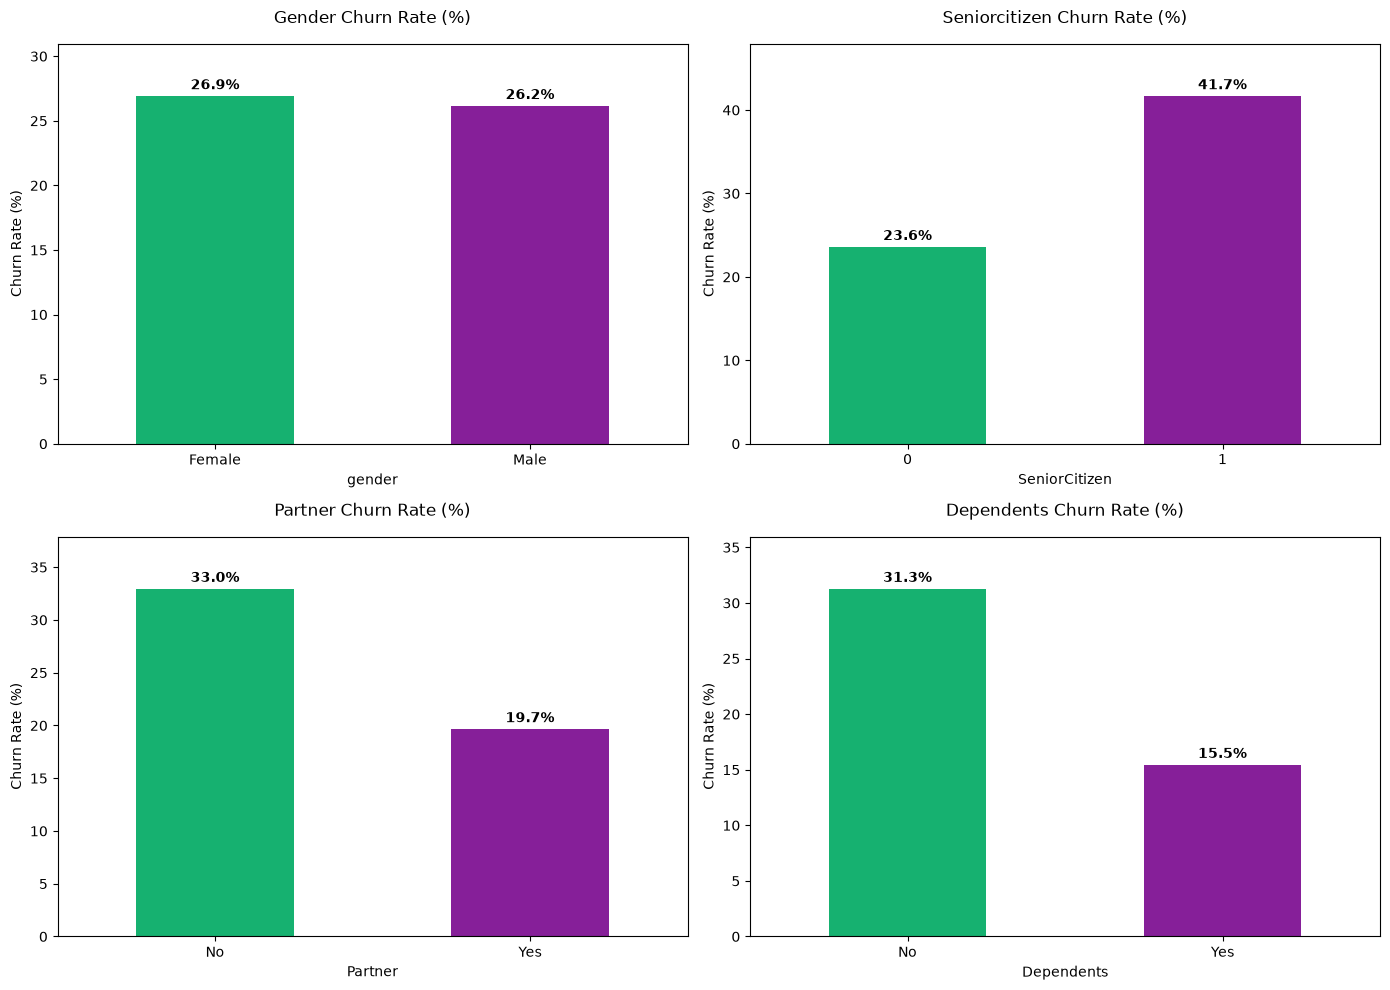

In [8]:
# Create a boolean target column where 'Yes' becomes True and 'No' becomes False
df["Churn_num"] = df["Churn"].astype(str).str.lower() == "yes"

# Plot churn rates for the demographic features
plot_categorical_churn_rates(df, demographic_features, 'Churn_num')

El análisis de la tasa de churn muestra diferencias importantes entre algunas de las categorías demográficas, aunque la magnitud de estas diferencias varía considerablemente entre variables.

En `gender`, las tasas de abandono son muy similares: 26.9% para mujeres y 26.2% para hombres. La diferencia de apenas 0.7 puntos porcentuales sugiere que, a nivel exploratorio, no existe una diferencia relevante en el comportamiento de abandono entre ambos grupos.

En `SeniorCitizen` se observa una diferencia considerable. Los clientes que no pertenecen al grupo de adultos mayores presentan una tasa de churn de 23.6%, mientras que aquellos que sí pertenecen a este grupo alcanzan un 41.7%. Esto representa una diferencia de 18.1 puntos porcentuales, lo que sugiere una posible asociación entre pertenecer al grupo de adultos mayores y una mayor tasa de abandono.

Para `Partner`, los clientes que no tienen pareja presentan una tasa de churn de 33.0%, frente a 19.7% entre aquellos que sí tienen pareja. La diferencia de 13.3 puntos porcentuales indica un patrón relevante que deberá considerarse en las siguientes etapas del análisis.

Finalmente, `Dependents` presenta una de las diferencias más marcadas. Los clientes sin dependientes tienen una tasa de churn de 31.3%, mientras que aquellos con dependientes presentan una tasa de 15.5%, una diferencia de 15.8 puntos porcentuales.

En conjunto, `gender` muestra una diferencia mínima en la tasa de abandono, mientras que `SeniorCitizen`, `Partner` y `Dependents` presentan diferencias considerablemente mayores. Estos resultados identifican patrones potencialmente relevantes para la predicción de churn, aunque no implican una relación causal. Su utilidad predictiva deberá evaluarse posteriormente junto con el resto de las variables disponibles y mediante técnicas de modelado.

### 5.3 Análisis estadístico de variables demográficas

El análisis de las distribuciones y las tasas de churn permitió identificar diferencias entre las categorías de cada variable demográfica. Sin embargo, estas diferencias descriptivas no permiten determinar por sí solas si existe evidencia estadística de una asociación con el abandono del servicio.

Para complementar el análisis exploratorio, se aplicará la prueba Chi-cuadrado de independencia a cada una de las variables demográficas. Esta prueba permitirá evaluar si existe una asociación estadísticamente significativa entre cada característica y la variable objetivo `Churn`.

Para cada variable demográfica se plantearán las siguientes hipótesis:

$$
H_0: \text{La variable demográfica y Churn son independientes.}
$$

$$
H_1: \text{La variable demográfica y Churn no son independientes.}
$$

Por ejemplo, para la variable `Partner`, la prueba busca responder la siguiente pregunta:

> ¿La categoría de `Partner` está asociada estadísticamente con el hecho de que un cliente abandone o no el servicio?

Un p-value inferior al nivel de significancia establecido ($\alpha = 0.05$) proporcionará evidencia suficiente para rechazar la hipótesis nula y considerar que existe una asociación estadísticamente significativa entre la variable analizada y `Churn`.

Sin embargo, el p-value no indica qué tan fuerte es dicha asociación. Por esta razón, se utilizará Cramér's V como medida del tamaño o fuerza de la asociación. Mientras que el p-value permite determinar si existe evidencia estadística de una asociación, Cramér's V permite evaluar la magnitud de dicha asociación, independientemente del tamaño de la muestra. Esto permitirá distinguir entre asociaciones estadísticamente significativas pero de baja magnitud y aquellas que presentan una relación más fuerte.

Para facilitar su interpretación, se utilizarán como referencia los puntos de corte propuestos por Jacob Cohen, adaptados como una guía heurística para este análisis:

| Cramér's V | Interpretación |
|---:|---|
| $V < 0.10$ | Muy baja |
| $0.10 \leq V < 0.30$ | Baja |
| $0.30 \leq V < 0.50$ | Moderada |
| $V \geq 0.50$ | Fuerte |

<br>

> **Nota metodológica:** Los puntos de corte utilizados para interpretar el valor de Cramér's V se emplearán únicamente como una referencia heurística para facilitar la interpretación de la magnitud de las asociaciones. Estos umbrales no constituyen criterios universales y deben interpretarse considerando el contexto del problema, las dimensiones de la tabla de contingencia y la magnitud práctica de la asociación.

Los resultados se utilizarán para identificar qué variables demográficas presentan evidencia de asociación con el churn y evaluar la magnitud de dichas asociaciones. Estos resultados serán considerados junto con los demás análisis exploratorios y no se utilizarán, por sí solos, como criterio definitivo para seleccionar o descartar variables del modelo.

In [ ]:
# Perform Chi-square test to analyze relationship with customer churn
statistical_results = chi_square_analysis(
    df=df,
    features=demographic_features,
    target="Churn"
)

# Print results
statistical_results


,Variable,Chi-Square,p-value,Cramer's V,Asociación
0,gender,0.484083,4.865787e-01,0.008291,Muy baja
1,SeniorCitizen,159.426300,1.510067e-36,0.150453,Baja
2,Partner,158.733382,2.139911e-36,0.150126,Baja
3,Dependents,189.129249,4.924922e-43,0.163870,Baja


Los resultados de la prueba Chi-cuadrado de independencia muestran diferencias importantes entre las variables demográficas analizadas.

En el caso de `gender`, se obtuvo un p-value de 0.4866, superior al nivel de significancia establecido de $\alpha = 0.05$. Por lo tanto, no se rechaza la hipótesis nula de independencia. Además, el valor de Cramér's V = 0.0083 indica una asociación muy baja. En conjunto, no se observa evidencia estadística de una asociación relevante entre el género del cliente y `Churn`.

Para `SeniorCitizen`, el *p-value es prácticamente cero ($1.51 \times 10^{-36}$)*, por lo que se rechaza la hipótesis nula de independencia. Existe evidencia estadística de una asociación entre esta variable y `Churn`. Sin embargo, el valor de Cramér's V = 0.1505 indica que la magnitud de esta asociación es baja. Esto es consistente con el análisis anterior, donde los clientes adultos mayores presentaron una tasa de churn considerablemente superior.

En `Partner` también se observa evidencia estadística de asociación con `Churn`, con un p-value de $2.14 \times 10^{-36}$. El valor de Cramér's V = 0.1501 indica una asociación de magnitud baja. Por lo tanto, aunque las diferencias observadas en las tasas de churn son estadísticamente significativas, la variable presenta por sí sola una asociación relativamente limitada con el abandono.

Finalmente, `Dependents` presenta el mayor valor de Cramér's V entre las variables analizadas (**0.1639**), aunque la magnitud de la asociación continúa siendo baja según los criterios establecidos. Su p-value de $4.92 \times 10^{-43}$** proporciona evidencia estadística muy fuerte para rechazar la hipótesis de independencia.

En conjunto, los resultados muestran que `SeniorCitizen`, `Partner` y `Dependents` presentan asociaciones estadísticamente significativas con `Churn`, mientras que `gender` no presenta evidencia suficiente de asociación. Sin embargo, ninguna de las variables demográficas presenta una asociación de magnitud moderada o fuerte de manera individual.

Esto sugiere que el abandono probablemente responde a la combinación de múltiples características del cliente, en lugar de estar determinado principalmente por una sola variable demográfica.

## 6. Análisis de Variables de Cuenta

In [23]:
account_features = ['tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod']

In [26]:
for var in account_features:
    print(df[var].value_counts())
    print("")

tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

